# Autism Spectrum Disorder (ASD) Prediction using Machine Learning

This notebook builds predictive models to detect Autism Spectrum Disorder using behavioral screening features.

Models Used:
- Random Forest
- XGBoost

Evaluation Methods:
- Precision-Recall AUC
- Confusion Matrix
- Classification Report

Explainable AI:
- SHAP Feature Importance
- SHAP Local Explanations


# Import Libraries

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, average_precision_score,
     PrecisionRecallDisplay
)
import xgboost as xgb
import shap

# Load Dataset
- The dataset was got from kaggle : Autism Screening in Toddlers

In [9]:
DATA_PATH = "../data/asd.csv"
TARGET_COL  = "Diagnosed_ASD"

df = pd.read_csv(DATA_PATH)
df = df.drop(columns=["Child_ID", "Unnamed: 10"], errors='ignore')

print("\n")
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape}")
print(df.head())



DATASET OVERVIEW
Shape: (1000, 9)
   Age  Gender Jaundice Family_ASD_History Language_Delay  \
0   18    Male       No                 No             No   
1   31  Female      Yes                 No             No   
2   26    Male      Yes                Yes             No   
3   22  Female      Yes                Yes            Yes   
4   19  Female      Yes                Yes            Yes   

   Social_Interaction_Score  Communication_Score  Repetitive_Behavior_Score  \
0                         5                    4                          8   
1                         7                    6                          4   
2                         4                    5                          5   
3                         4                    7                          4   
4                         2                    1                          9   

  Diagnosed_ASD  
0            No  
1            No  
2           Yes  
3            No  
4            No  


# Data Preprocessing
-Here we had to ensure data quality, avoid bias and improve model reliability.

In [10]:
#  Missing-value imputation
categorical_cols = ['Gender', 'Jaundice', 'Family_ASD_History', 'Language_Delay']
numeric_cols_raw = ['Age', 'Social_Interaction_Score',
                    'Communication_Score', 'Repetitive_Behavior_Score']

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

for col in numeric_cols_raw:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

#  Encode categorical features
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Encode binary target (Yes=1, No=0)
df[TARGET_COL] = LabelEncoder().fit_transform(df[TARGET_COL])
# NOTE: LabelEncoder maps alphabetically : "No"=0, "Yes"=1

print("\nTarget class distribution (raw):")
print(df[TARGET_COL].value_counts())


Target class distribution (raw):
Diagnosed_ASD
0    589
1    411
Name: count, dtype: int64


# Feature Split

In [11]:
# Features / Target split
X = df.drop(TARGET_COL, axis=1)
y = df[TARGET_COL]

# Scale numeric features
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# PART 1 — ALGORITHM SELECTION & TRAINING

In [12]:
print("\n")
print("PART 1: MODEL TRAINING")
print("=" * 60)

#  Stratified Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test  set: {X_test.shape[0]}  samples")
print(f"Train class ratio (ASD=1): {y_train.mean():.2%}")
print(f"Test  class ratio (ASD=1): {y_test.mean():.2%}")



PART 1: MODEL TRAINING

Train set: 800 samples
Test  set: 200  samples
Train class ratio (ASD=1): 41.12%
Test  class ratio (ASD=1): 41.00%


#  Model 1: Random Forest
-Here we were training the Random Forest algorithm

In [13]:
rf_model = RandomForestClassifier(
    n_estimators=400,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)
print("\n✔ Random Forest trained (n_estimators=400, class_weight='balanced')")



✔ Random Forest trained (n_estimators=400, class_weight='balanced')


# Model 2: XGBoost
- Here we were training the XGBoost model

In [14]:
neg   = int((y_train == 0).sum())
pos   = int((y_train == 1).sum())
ratio = float(neg) / float(pos)
print(f"\nXGBoost scale_pos_weight = {neg}/{pos} = {ratio:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    scale_pos_weight=ratio,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)
print(" XGBoost trained (n_estimators=400, scale_pos_weight={:.2f})".format(ratio))



XGBoost scale_pos_weight = 471/329 = 1.43
 XGBoost trained (n_estimators=400, scale_pos_weight=1.43)


# PART 2 — ADVANCED EVALUATION METRICS

In [15]:
print("\n")
print("PART 2: EVALUATION — PR-AUC, Confusion Matrix, F1")
print("=" * 60)

rf_probs  = rf_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
rf_preds  = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

# PR-AUC
rf_prauc  = average_precision_score(y_test, rf_probs)
xgb_prauc = average_precision_score(y_test, xgb_probs)

print(f"\nRandom Forest PR-AUC : {rf_prauc:.3f}")
print(f"XGBoost       PR-AUC : {xgb_prauc:.3f}")



PART 2: EVALUATION — PR-AUC, Confusion Matrix, F1

Random Forest PR-AUC : 0.348
XGBoost       PR-AUC : 0.350


# Precision-Recall Curves

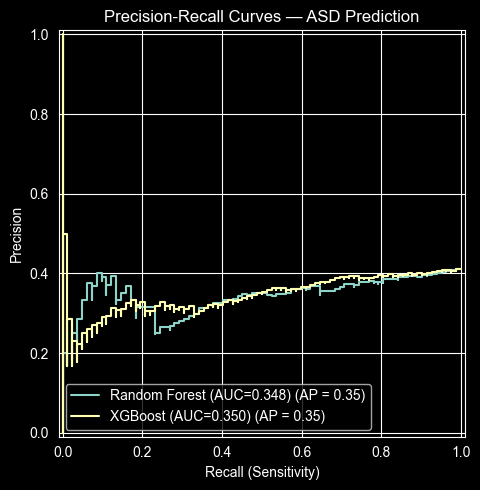

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
PrecisionRecallDisplay.from_predictions(
    y_test, rf_probs,  ax=ax, name=f"Random Forest (AUC={rf_prauc:.3f})")
PrecisionRecallDisplay.from_predictions(
    y_test, xgb_probs, ax=ax, name=f"XGBoost (AUC={xgb_prauc:.3f})")
ax.set_title("Precision-Recall Curves — ASD Prediction")
ax.set_xlabel("Recall (Sensitivity)")
ax.set_ylabel("Precision")
plt.tight_layout()
plt.savefig("../outputs/pr_curves.png", dpi=150)
plt.show()

#  Confusion Matrices

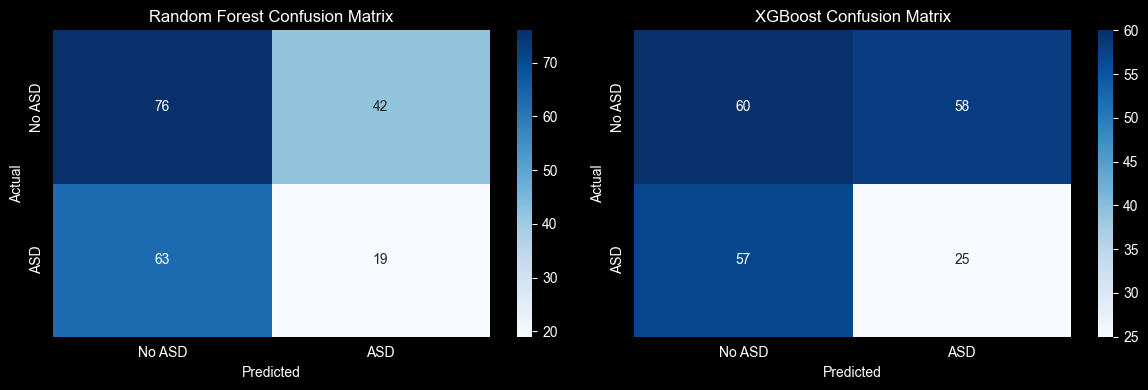

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, preds, title in zip(
        axes,
        [rf_preds, xgb_preds],
        ["Random Forest", "XGBoost"]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No ASD', 'ASD'],
                yticklabels=['No ASD', 'ASD'])
    ax.set_title(f"{title} Confusion Matrix")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")
plt.tight_layout()
plt.savefig("../outputs/confusion_matrices.png", dpi=150)
plt.show()


# Classification Reports

In [18]:
print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, rf_preds, target_names=['No ASD', 'ASD']))

print("--- XGBoost Classification Report ---")
print(classification_report(y_test, xgb_preds, target_names=['No ASD', 'ASD']))



--- Random Forest Classification Report ---
              precision    recall  f1-score   support

      No ASD       0.55      0.64      0.59       118
         ASD       0.31      0.23      0.27        82

    accuracy                           0.47       200
   macro avg       0.43      0.44      0.43       200
weighted avg       0.45      0.47      0.46       200

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

      No ASD       0.51      0.51      0.51       118
         ASD       0.30      0.30      0.30        82

    accuracy                           0.42       200
   macro avg       0.41      0.41      0.41       200
weighted avg       0.43      0.42      0.43       200



# Summary Table

In [19]:
summary = pd.DataFrame({
    "Model"    : ["Random Forest", "XGBoost"],
    "Accuracy" : [accuracy_score(y_test, rf_preds),
                  accuracy_score(y_test, xgb_preds)],
    "PR-AUC"   : [rf_prauc, xgb_prauc]
})
print("\n── Model Comparison Summary ──")
print(summary.to_string(index=False))



── Model Comparison Summary ──
        Model  Accuracy   PR-AUC
Random Forest     0.475 0.347916
      XGBoost     0.425 0.349622


# PART 3 — EXPLAINABLE AI WITH SHAP



PART 3: SHAP — MODEL EXPLAINABILITY


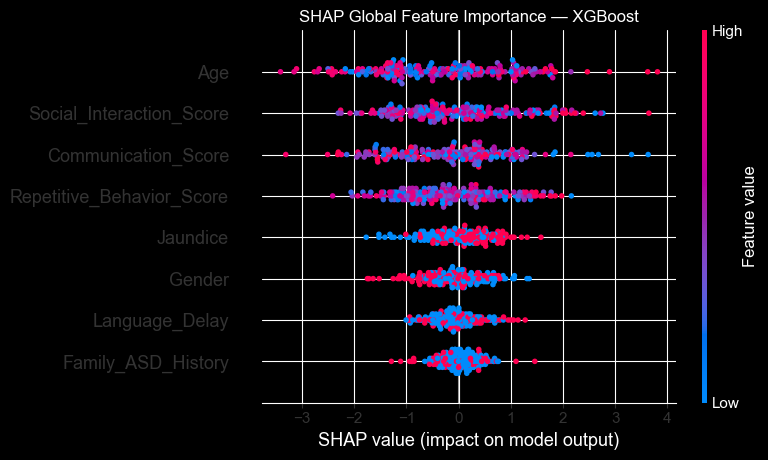

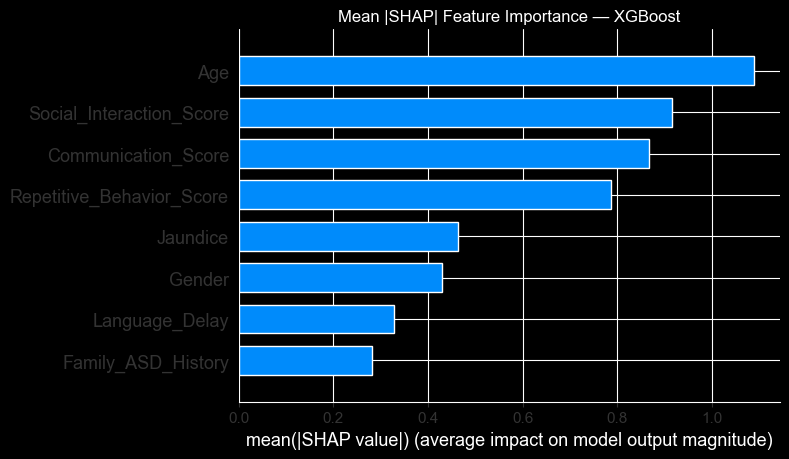

In [21]:
print("\n")
print("PART 3: SHAP — MODEL EXPLAINABILITY")
print("=" * 60)

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)

# Beeswarm (Global)
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Global Feature Importance — XGBoost")
plt.tight_layout()
plt.savefig("../outputs/shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()

#  Bar Plot (Global)
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Mean |SHAP| Feature Importance — XGBoost")
plt.tight_layout()
plt.savefig("../outputs/shap_bar.png", dpi=150, bbox_inches='tight')
plt.show()

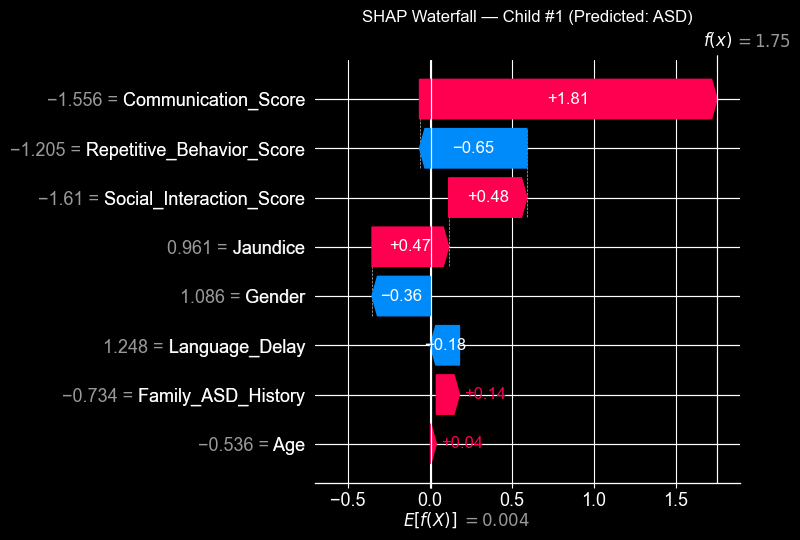

In [22]:
#  Waterfall — ASD child
asd_indices = np.where(xgb_preds == 1)[0]
row_index   = int(asd_indices[0]) if len(asd_indices) > 0 else 5

plt.figure()
shap.plots.waterfall(shap_values[row_index], show=False)
plt.title(f"SHAP Waterfall — Child #{row_index} (Predicted: ASD)")
plt.tight_layout()
plt.savefig("../outputs/shap_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()


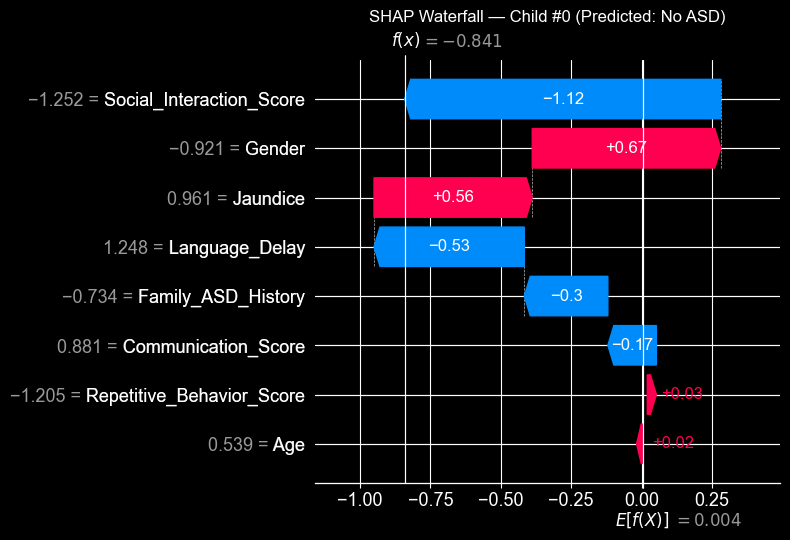

In [23]:
# Waterfall — Non-ASD child
non_asd_indices = np.where(xgb_preds == 0)[0]
row_index2      = int(non_asd_indices[0]) if len(non_asd_indices) > 0 else 0

plt.figure()
shap.plots.waterfall(shap_values[row_index2], show=False)
plt.title(f"SHAP Waterfall — Child #{row_index2} (Predicted: No ASD)")
plt.tight_layout()
plt.savefig("../outputs/shap_waterfall_noasd.png", dpi=150, bbox_inches='tight')
plt.show()


<Figure size 800x500 with 0 Axes>

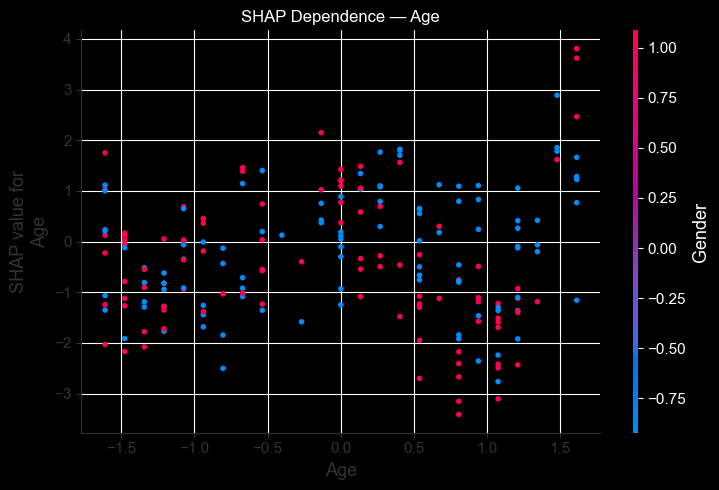



IMAGE OUTPUTS
Outputs saved to: ../outputs/


In [24]:
# Dependence Plot
top_feature = X_test.columns[
    np.abs(shap_values.values).mean(axis=0).argmax()
]
plt.figure(figsize=(8, 5))
shap.dependence_plot(top_feature, shap_values.values, X_test, show=False)
plt.title(f"SHAP Dependence — {top_feature}")
plt.tight_layout()
plt.savefig("../outputs/shap_dependence.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n")
print("IMAGE OUTPUTS")
print("Outputs saved to: ../outputs/")
print("=" * 60)
